<b><font color="green">🥑 АНАЛИЗ КОНКУРЕНТОВ 🥑</font></b>

Наш проект — салат-бар со шведским столом и оплатой за вес.

Разделим конкурентов на 2 уровня:
1) Прямые — салат-бары с оплатой за вес (та же модель): ❌ не найдены в России
2) Косвенные — тот же продукт - healthy food (салаты, боулы), другая модель оплаты: ✅ найдены в России (Avocado Cafe, Good Food Bowl, Salatnica)

В ходе анализа рынка было установлено, что модели «шведский стол с оплатой за вес» в сегменте салат-баров в России не представлены (🎉)!!

Существующие заведения работают по модели фиксированного меню (готовые боулы) или конструктора за фиксированную цену

**Это подтверждает, что GREEN-WEIGHT-PROJECT выходит на рынок с уникальной бизнес-моделью, формируя новую нишу.**

СЕЛЕНИУМ подключаем

In [3]:
!apt-get update -qq
!apt-get install -y -qq chromium-browser chromium-chromedriver
!pip install selenium -q

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
Selecting previously unselected package apparmor.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../apparmor_3.0.4-2ubuntu2.5_amd64.deb ...
Unpacking apparmor (3.0.4-2ubuntu2.5) ...
Selecting previously unselected package squashfs-tools.
Preparing to unpack .../squashfs-tools_1%3a4.5-3build1_amd64.deb ...
Unpacking squashfs-tools (1:4.5-3build1) ...
Selecting previously unselected package udev.
Preparing to unpack .../udev_249.11-0ubuntu3.20_amd64.deb ...
Unpacking udev (249.11-0ubuntu3.20) ...
Selecting previously unselected package libfuse3-3:amd64.
Preparing to unpack .../libfuse3-3_3.10.5-1build1_amd64.deb ...
Unpacking libfuse3-3:amd64 (3.10.5-1build1) ...
Selecting previously unselected package snapd.
Preparing to unpack

In [4]:
# браузер Chrome
# для Google Colab добавляю:
!apt-get update
!apt-get install -y wget unzip xvfb libxi6 libgconf-2-4
!wget -q -O - https://dl-ssl.google.com/linux/linux_signing_key.pub | apt-key add -
!echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google.list
!apt-get update
!apt-get install -y google-chrome-stable

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,723 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libxi6 is already the newest version (2:1.8-1build

In [5]:
!apt-get install -y -qq chromium-browser chromium-chromedriver

🥗🥑🥗 Выведем информацию о салатах у наших косвенных конкурентов и посмотрим на статистику (там, где есть информация о граммовке и цене - выведем цену за 100 г и сравним с нашей; там, где есть только цена - посмотрим средний чек за порцию у конкурента и сравним с ценой за наши 350 г) :

Кафе "Авокадо" (салаты)

In [18]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
import time
import re

print("ПАРСИНГ AVOCADO CAFE (ЦЕНА, ВЕС, ЦЕНА ЗА 100г)")
print("="*60)

options = Options()
options.add_argument('--headless')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.binary_location = '/usr/bin/chromium-browser'

driver = webdriver.Chrome(options=options)
driver.get("https://avocadocafe.ru/takeaway#!/tab/683817402-1")
time.sleep(8)

text = driver.find_element(By.TAG_NAME, "body").text
blocks = re.split(r'Заказать', text)

dishes = []

for block in blocks:
    if '₽' not in block:
        continue

    # Цена
    price_match = re.search(r'(\d+)\s*₽', block)
    if not price_match:
        continue
    price = int(price_match.group(1))

    # Вес
    weight_match = re.search(r'(\d+)\s*гр', block)
    if not weight_match:
        continue
    weight = int(weight_match.group(1))

    # Цена за 100г
    price_per_100g = round((price / weight) * 100, 1)

    # Название
    lines = block.strip().split('\n')
    name = None
    for line in lines:
        line = line.strip()
        if (len(line) > 5 and re.match(r'[А-ЯЁ]', line) and 'Артикул' not in line and not re.match(r'\d', line)):
            name = line
            break

    if name and price and weight:
        dishes.append({
            'name': name,
            'price': price,
            'weight_g': weight,
            'price_per_100g': price_per_100g
        })

driver.quit()

# выводим таблицу
print("МЕНЮ AVOCADO CAFE")
for d in dishes:
    print(f"{d['name']}")
    print(f"   {d['price']} ₽ | {d['weight_g']} г | {d['price_per_100g']} ₽ за 100г\n")

# статистика
if dishes:
    prices_per_100g = [d['price_per_100g'] for d in dishes]
    avg = sum(prices_per_100g) / len(prices_per_100g)
    min_price = min(prices_per_100g)
    max_price = max(prices_per_100g)

    print("СТАТИСТИКА")
    print(f"Средняя цена за 100г: {avg:.1f} ₽")
    print(f"Минимум за 100г: {min_price:.1f} ₽")
    print(f"Максимум за 100г: {max_price:.1f} ₽")

    # сравнение с нашим проектом
    print("\n" + "="*60)
    print("СРАВНЕНИЕ С GREEN-WEIGHT-PROJECT")
    our_price = 120
    print(f"Наша цена за 100г: {our_price} ₽")
    print(f"Средняя цена Avocado: {avg:.1f} ₽")
    print(f"Мы дешевле на {avg - our_price:.1f} ₽ за 100г")

ПАРСИНГ AVOCADO CAFE (ЦЕНА, ВЕС, ЦЕНА ЗА 100г)
МЕНЮ AVOCADO CAFE
Онлайн-заказ
   650 ₽ | 270 г | 240.7 ₽ за 100г

СЛАДКИЙ САЛАТ ИЗ ШПИНАТА, МАНГО И АВОКАДО
   690 ₽ | 250 г | 276.0 ₽ за 100г

САЛАТ С ЗАПЕЧЁННЫМИ ОВОЩАМИ И СЫРОМ ДОРБЛЮ
   780 ₽ | 220 г | 354.5 ₽ за 100г

САЛАТ ИЗ АВОКАДО И БАЗИЛИКОВОЙ ЗАПРАВКОЙ
   720 ₽ | 200 г | 360.0 ₽ за 100г

САЛАТ ИЗ АВОКАДО С МАКОМ И ОРЕХАМИ
   720 ₽ | 145 г | 496.6 ₽ за 100г

СТАТИСТИКА
Средняя цена за 100г: 345.6 ₽
Минимум за 100г: 240.7 ₽
Максимум за 100г: 496.6 ₽

СРАВНЕНИЕ С GREEN-WEIGHT-PROJECT
Наша цена за 100г: 120 ₽
Средняя цена Avocado: 345.6 ₽
Мы дешевле на 225.6 ₽ за 100г


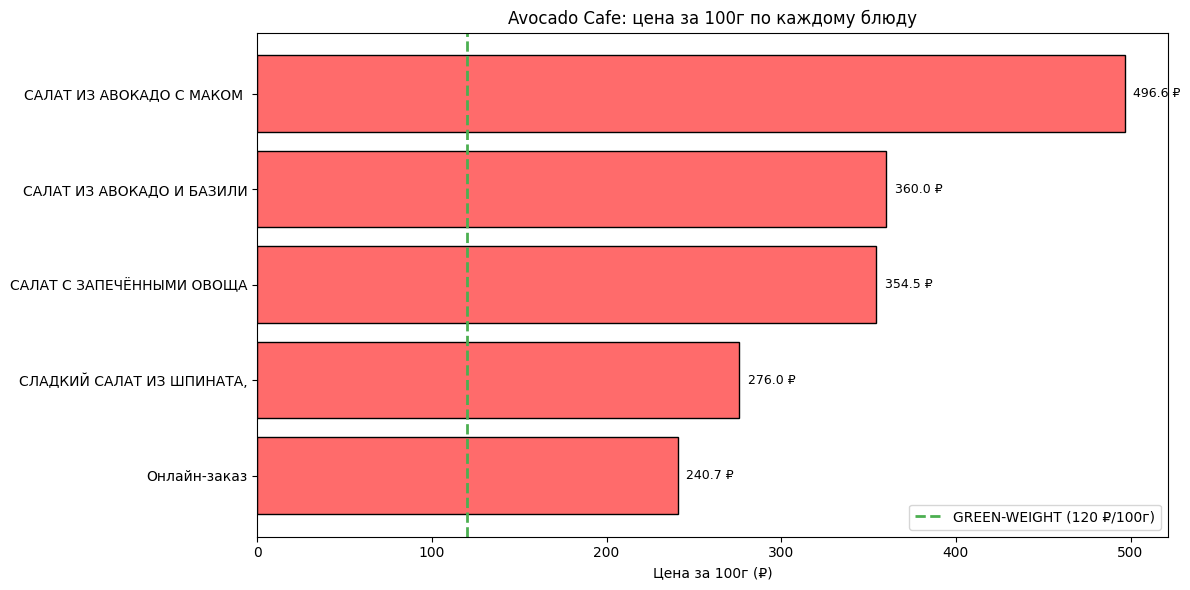

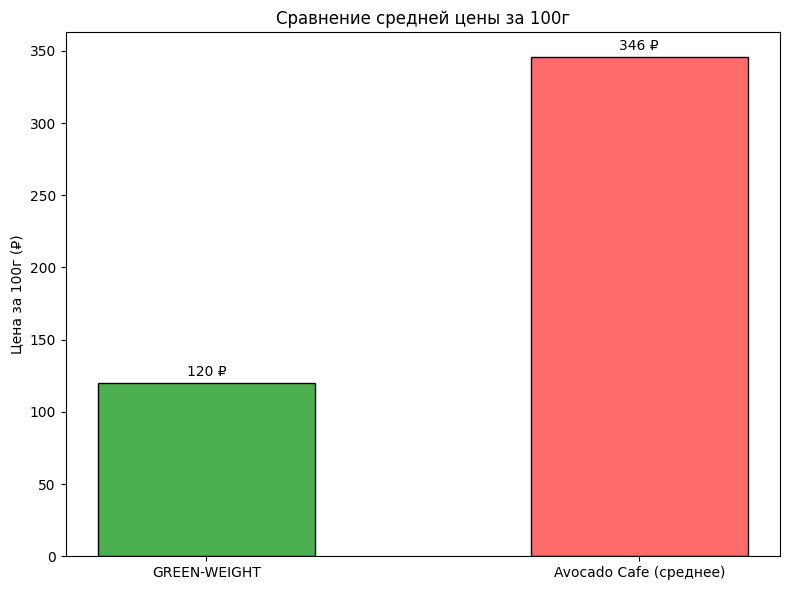

In [21]:
# графики
names = [d['name'][:25] for d in dishes]
prices_vals = [d['price_per_100g'] for d in dishes]

# График 1: сравнение каждого блюда
plt.figure(figsize=(12, 6))
bars = plt.barh(names, prices_vals, color='#FF6B6B', edgecolor='black')
plt.axvline(x=our_price, color='#4CAF50', linestyle='--', linewidth=2, label=f'GREEN-WEIGHT ({our_price} ₽/100г)')
plt.xlabel('Цена за 100г (₽)')
plt.title('Avocado Cafe: цена за 100г по каждому блюду')
for bar, val in zip(bars, prices_vals):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{val} ₽', va='center', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

# График 2: среднее сравнение
plt.figure(figsize=(8, 6))
categories = ['GREEN-WEIGHT', 'Avocado Cafe (среднее)']
values = [our_price, avg]
colors = ['#4CAF50', '#FF6B6B']
bars = plt.bar(categories, values, color=colors, edgecolor='black', width=0.5)
plt.ylabel('Цена за 100г (₽)')
plt.title('Сравнение средней цены за 100г')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f} ₽', ha='center')
plt.tight_layout()
plt.show()

Вывод по графикам Avocado Cafe:
- Самое дорогое блюдо — «Салат из авокадо с маком»: почти 497 ₽ за 100г
- Разброс цен составляет от 241 до 497 ₽ за 100г

Сравнение средней цены с GREEN-WEIGHT:
- Средняя цена Avocado Cafe: 346 ₽ за 100г
- Наша цена: 120 ₽ за 100г
- Разница: 215 ₽ в нашу пользу! 🎉

ГЛАВНЫЙ ВЫВОД: GREEN-WEIGHT в ~2,8 раза дешевле Avocado Cafe по цене за 100г. Это достигается за счёт формата оплаты за вес и отсутствия наценки на недоеденные остатки.

Good Food Bowl (салаты)

In [25]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
import time
import re

print("ПАРСИНГ GOOD FOOD BOWL (САЛАТЫ + СРАВНЕНИЕ)")
print("="*60)

options = Options()
options.add_argument('--headless')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.binary_location = '/usr/bin/chromium-browser'

driver = webdriver.Chrome(options=options)
driver.get("https://goodfoodbowl.ru/#salad")
time.sleep(8)

# получаю текст страницы
text = driver.find_element(By.TAG_NAME, "body").text
lines = text.split('\n')

salads = []
prices = []

keywords = ['салат', 'salad', 'микс', 'овощной', 'зеленый', 'с листьями']

for i, line in enumerate(lines):
    if '₽' in line:
        price_match = re.search(r'(\d+)\s*₽', line)
        if price_match:
            price = int(price_match.group(1))
            name = lines[i-1].strip() if i > 0 else ""

            if name and len(name) > 3:
                name_lower = name.lower()
                if any(keyword in name_lower for keyword in keywords):
                    if name not in [s.split(' —')[0] for s in salads]:
                        salads.append(f"{name} — {price} ₽")
                        prices.append(price)

driver.quit()

# вывожу салаты из меню
print(f"НАЙДЕНО САЛАТОВ: {len(salads)}")
for salad in salads[:20]:
    print(salad)

# статистика и сравнение
if prices:
    avg_price = sum(prices) / len(prices)
    min_price = min(prices)
    max_price = max(prices)


    print("СТАТИСТИКА ПО GOOD FOOD BOWL(салатики)")
    print("="*60)
    print(f"Средняя цена за порцию: {avg_price:.0f} ₽")
    print(f"Минимальная цена: {min_price} ₽")
    print(f"Максимальная цена: {max_price} ₽")

    print("СРАВНЕНИЕ С GREEN-WEIGHT-PROJECT")
    print("="*60)

    # делаю так, тк на сайте нет информации о граммовках((
    # наш проект: средний вес тарелки 350г, цена 120₽/100г
    our_avg_check = 120 * 3.5  # то есть 420 ₽ за тарелку 350г
    print(f"GREEN-WEIGHT (средний чек за тарелку 350г): {our_avg_check:.0f} ₽")
    print(f"Good Food Bowl (средний чек за порцию): {avg_price:.0f} ₽")

    if avg_price > our_avg_check:
        print(f"Мы дешевле конкурента в среднем на {avg_price - our_avg_check:.0f} ₽")
    else:
        print(f"Конкурент дешевле на {our_avg_check - avg_price:.0f} ₽")



ПАРСИНГ GOOD FOOD BOWL (САЛАТЫ + СРАВНЕНИЕ)
НАЙДЕНО САЛАТОВ: 6
Neo Tuna Salad w Puffed Rise — 790 ₽
Avocado & Orange Salad — 830 ₽
Vegan Salmon Salad (Neo Fish salad) — 650 ₽
Vegan Unagi Salad w Сream Сheese — 690 ₽
Ginger-Almond Salad — 690 ₽
Ricotta Salad — 590 ₽
СТАТИСТИКА ПО GOOD FOOD BOWL(салатики)
Средняя цена за порцию: 707 ₽
Минимальная цена: 590 ₽
Максимальная цена: 830 ₽
СРАВНЕНИЕ С GREEN-WEIGHT-PROJECT
GREEN-WEIGHT (средний чек за тарелку 350г): 420 ₽
Good Food Bowl (средний чек за порцию): 707 ₽
Мы дешевле конкурента в среднем на 287 ₽


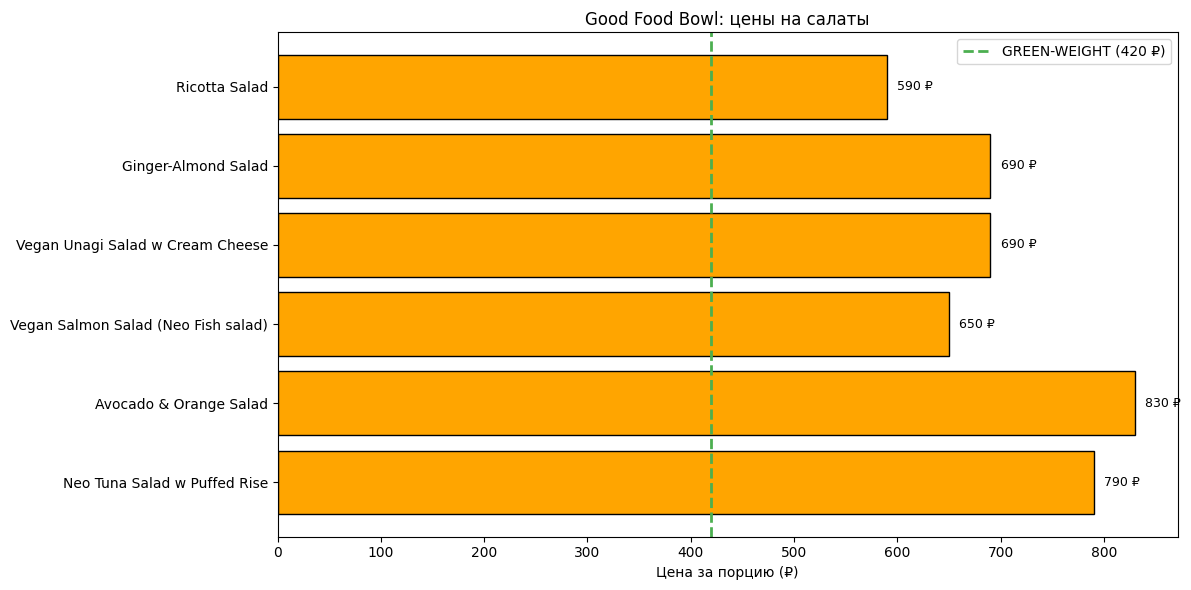

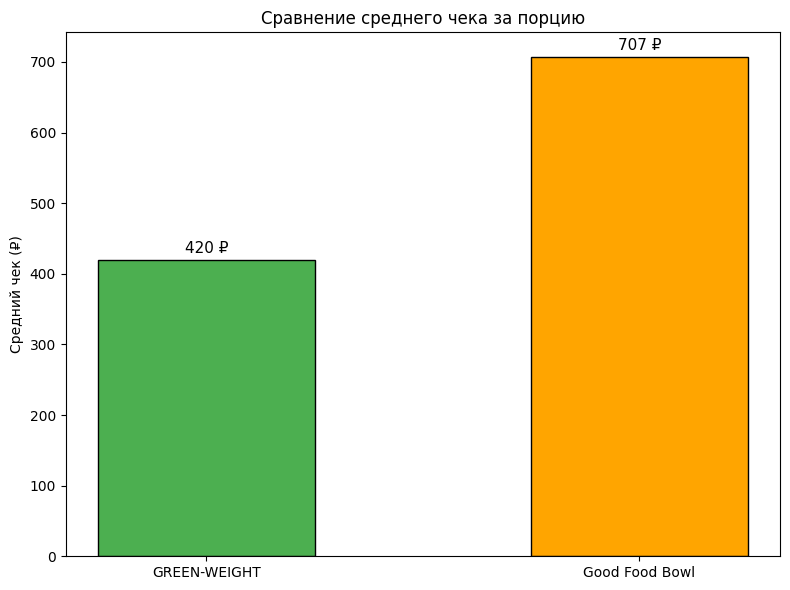

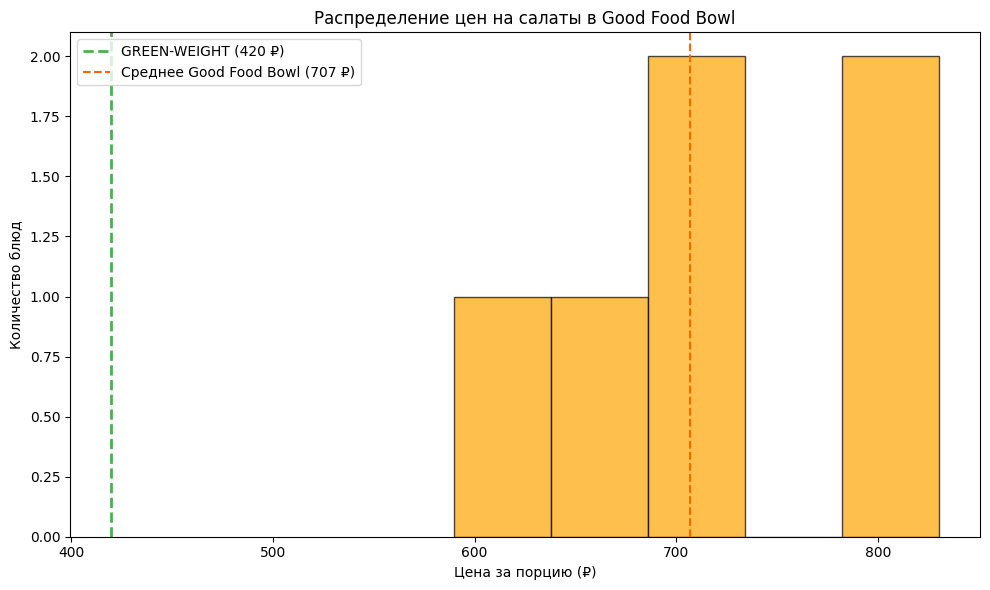

In [28]:
import matplotlib.pyplot as plt


# График 1: цены по каждому салату
plt.figure(figsize=(12, 6))
names_only = [s.split(' —')[0] for s in salads[:10]]
prices_only = prices[:10]
bars = plt.barh(names_only, prices_only, color='#FFA500', edgecolor='black')
plt.axvline(x=our_avg_check, color='#4CAF50', linestyle='--', linewidth=2, label=f'GREEN-WEIGHT ({our_avg_check:.0f} ₽)')
plt.xlabel('Цена за порцию (₽)')
plt.title('Good Food Bowl: цены на салаты')
for bar, val in zip(bars, prices_only):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, f'{val} ₽', va='center', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

# График 2: сравнение средних чеков
plt.figure(figsize=(8, 6))
categories = ['GREEN-WEIGHT', 'Good Food Bowl']
values = [our_avg_check, avg_price]
colors_bar = ['#4CAF50', '#FFA500']
bars = plt.bar(categories, values, color=colors_bar, edgecolor='black', width=0.5)
plt.ylabel('Средний чек (₽)')
plt.title('Сравнение среднего чека за порцию')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:.0f} ₽', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# График 3: распределение цен
plt.figure(figsize=(10, 6))
plt.hist(prices, bins=5, color='#FFA500', edgecolor='black', alpha=0.7)
plt.axvline(x=our_avg_check, color='#4CAF50', linestyle='--', linewidth=2, label=f'GREEN-WEIGHT ({our_avg_check:.0f} ₽)')
plt.axvline(x=avg_price, color='#FF6600', linestyle='--', linewidth=1.5, label=f'Среднее Good Food Bowl ({avg_price:.0f} ₽)')
plt.xlabel('Цена за порцию (₽)')
plt.ylabel('Количество блюд')
plt.title('Распределение цен на салаты в Good Food Bowl')
plt.legend()
plt.tight_layout()
plt.show()

Вывод по графикам Good Food Bowl:
- Самое дорогое блюдо — «Avocado & Orange Salad»: 830 ₽
- Все салаты находятся в ценовом диапазоне 590–830 ₽ за порцию

Сравнение среднего чека с GREEN-WEIGHT:
- Средняя цена Good Food Bowl: 707 ₽ за порцию
- Наша средняя цена: 420 ₽ за тарелку (350 г)
- Разница: 287 ₽ в нашу пользу!🎉

Гистограмма распределения цен показывает, что наш проект (420 ₽) находится значительно ниже всего ценового диапазона конкурента - нет ни одного блюда, близкого по цене к GREEN-WEIGHT.


ГЛАВНЫЙ ВЫВОД: GREEN-WEIGHT в ~1,7 раза дешевле Good Food Bowl. При этом у конкурента нет информации о граммовках, что является большим минусом для клиентов, следящих за питанием, кбжу, которык хотят внести данные о приёме пищи в приложение (например, FatSecret). Наш формат с оплатой за вес и прозрачной ценой за 100г — более честный и понятный для потребителя.

Парсинг негативных отзывов из Salatnica (потом сделаем выводы с учётом их проблем):

In [40]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
import time
import re
from collections import Counter

print("ПАРСИНГ ОТЗЫВОВ SALATNICA (С ПОИСКОМ НЕГАТИВА)")
print("="*60)

options = Options()
options.add_argument('--headless')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.binary_location = '/usr/bin/chromium-browser'

driver = webdriver.Chrome(options=options)
driver.get("https://yandex.ru/maps/org/salatnica/23752707703/reviews/")
time.sleep(8)

# прокручиваем
for _ in range(3):
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(3)

reviews = driver.find_elements(By.CSS_SELECTOR, "[data-testid='review-card']")
if not reviews:
    reviews = driver.find_elements(By.CLASS_NAME, "business-review-view")

print(f"Всего найдено отзывов: {len(reviews)}")

# список ключевых слов
negative_keywords = [
    'дорого', 'кусаются', 'дорогой', 'цены', 'переплата',
    'небольшие порции', 'маленькие порции', 'не наелся', 'неприветливый'
    'гнилое', 'просроченный', 'испорченный', 'несвежий', 'тухлый',
    'горький', 'забродивший', 'пресный', 'безвкусный', 'сухой', 'сухая',
    'ужас', 'ужасно', 'отвратительно', 'разочарование', 'не советую',
    'хамство', 'грубый', 'не вежливо', 'долго ждать',
    'наличные', 'сдачи нет', 'только наличные', 'overprice'
]

negative_reviews = []
all_keywords_found = []

for review in reviews[:50]:
    try:
        text = review.text
        if not text:
            continue

        text_lower = text.lower()
        found_words = [kw for kw in negative_keywords if kw in text_lower]

        if found_words:
            negative_reviews.append({
                'text': text[:400],
                'keywords': found_words
            })
            all_keywords_found.extend(found_words)
            print(f"\n⚠️НАЙДЕНЫ: {', '.join(found_words)}")
            print(f"Текст: {text[:200]}...")
            print("-"*40)
    except:
        pass

driver.quit()

# сохраняю
with open('negative_reviews.txt', 'w', encoding='utf-8') as f:
    for rev in negative_reviews:
        f.write(f"Ключевые слова: {', '.join(rev['keywords'])}\n")
        f.write(f"Текст: {rev['text']}\n")
        f.write("="*50 + "\n")

# статистика ключевых слов по негативным отзывам
print("\n📊 СТАТИСТИКА КЛЮЧЕВЫХ СЛОВ (по всем негативным отзывам):")
for word, count in Counter(all_keywords_found).most_common(15):
    print(f"   {word}: {count} раз")

ПАРСИНГ ОТЗЫВОВ SALATNICA (С ПОИСКОМ НЕГАТИВА)
Всего найдено отзывов: 50

⚠️НАЙДЕНЫ: overprice
Текст: Полина А.
Level 5 Local Expert
Subscribe
March 19, 2025
This is so viral place on the Internet, so I couldn't miss the opportunity to visit this cafe. I was there with my friend on a weekday for a lun...
----------------------------------------

⚠️НАЙДЕНЫ: overprice
Текст: Nikita Shvetsov
Level 12 Local Expert
Subscribe
March 11
Overpriced. Mediocre food. Caesar salad served with tomatoes …
12
1
Show business's response...
----------------------------------------

⚠️НАЙДЕНЫ: цены
Текст: Рина
Level 28 Local Expert
Subscribe
April 3
во-первых, хочу сказать, что всё очень вкусное — что салаты, что напитки. цены не из дешевых, но еда соответствует качеству, а вот к смузи у меня остались ...
----------------------------------------

⚠️НАЙДЕНЫ: кусаются, цены
Текст: Дарина Литовченко
Level 10 Local Expert
Subscribe
February 15
Салат с креветками и манго изумительный, но порции относительно н